In [1]:
import torch

# DINOv2 with registers
dinov2_vits14_reg = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14_reg')
dinov2_vitb14_reg = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14_reg')
dinov2_vitl14_reg = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14_reg')
dinov2_vitg14_reg = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14_reg')

# 他フォルダの関数インポート手順　※__init__関数がある前提
# from ディレクトリ.pythonファイル import 関数名

Using cache found in /Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main
/Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Using cache found in /Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main


## ライブラリのインポート

In [2]:
import os, json
import numpy as np

import sys
if '..' not in sys.path:
    sys.path.append('..')

from PIL import Image
from io import BytesIO
from src.utils import draw_bounding_boxes, convert_4corners_to_x1y1x2y2
import matplotlib.pyplot as plt


import os
import json
from PIL import Image

import torch
import torch.nn as nn
import torchvision.ops as ops


from src.utils import (
    convert_4corners_to_x1y1x2y2, 
    get_features, 
    bboxes_tointeger, 
    compute_avg_conv_filter, 
    rescale_tensor,
    resize_conv_maps,
    rescale_bbox,
    ellipse_coverage
)

device = "cpu"

## Utilitiesの定義

In [3]:
def combine_pil_and_plot(original_img, density_map, title="", other_density_map=None):
    """
    - Convert the plot to a PIL image
    """
    # density_map をプロット
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(density_map)
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    ax.axis('off')

    # Matplotlib図をBytesIOに保存してPIL画像に変換
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    plot_image = Image.open(buf) # < plot_imageにdensity_mapが格納

    plt.close(fig)  # メモリ解放

    # オリジナル画像とdensity map画像を横に結合
    original_img = original_img.convert('RGB')
    plot_image = plot_image.resize(original_img.size)  # サイズを合わせる

    combined_width = original_img.width + plot_image.width
    combined_height = max(original_img.height, plot_image.height)
    combined = Image.new('RGB', (combined_width, combined_height), (255, 255, 255))
    combined.paste(original_img, (0, 0))
    combined.paste(plot_image, (original_img.width, 0))

    buf.close()  # バッファ解放
    return combined

In [4]:
def process_example(
    img_filename, entry, model, transform, map_keys, img_dir, density_map_dir, config, return_maps=False, gt_count=None
):
    """
    - when gt_count is not None, it is used to compute the metrics, and the density map is not used
    """
    # 1. 画像と密度マップの読込み
    img = Image.open(os.path.join(img_dir, img_filename)).convert('RGB')
    
    # 密度マップがない場合に正解のカウント数を指定することを求める条件分岐
    # 正解のカウント数が分からないなら、numpy形式の密度マップを読み込む処理を行う
    if density_map_dir is None:
        assert gt_count is not None, "gt_count must be provided if density_map_dir is None"
        #assert return_maps is False, "return_maps must be False if density_map_dir is None"
        density_map = None
    else:
        if gt_count is not None:
            print(f"Warning: gt_count is provided but density_map_dir is not None. Ignoring gt_count.")

        density_map = np.load(os.path.join(density_map_dir, f"{img_filename.split('.')[0]}.npy"))
    # 画像サイズから幅・高さを初期化
    w, h = img.size    

    # 2. 特徴量抽出
    # backboneモデルから特徴量マップを取得する
    with torch.no_grad():
        feats = get_features(
            model, img, transform, map_keys,
            divide_et_impera=config.divide_et_impera,
            divide_et_impera_twice=config.divide_et_impera_twice
        )
        # コサイン類似度／正規化を設定している場合は、L2正規化が行われる条件分岐
        if config.cosine_similarity or config.normalize_features:
            feats = feats / feats.norm(dim=1, keepdim=True)

    # 3. Exemplers(バウンディングボックス)の処理
    # アノテーションの座標形式を(x1,y1,x2,y2)に変換
    ex_bboxes = [convert_4corners_to_x1y1x2y2(b) for b in entry['box_examples_coordinates']]
    if config.num_exemplars is not None:
        assert config.num_exemplars > 0, "num_exemplars must be greater than 0. config.num_exemplars = " + config.num_exemplars
        ex_bboxes = ex_bboxes[:config.num_exemplars]
    # 画像サイズで正規化(特徴量マップのサイズにスケール変換、特徴量マップの解像度に合わせる)
    bboxes = np.array([(x1 / w, y1 / h, x2 / w, y2 / h) for x1, y1, x2, y2 in ex_bboxes]) * feats.shape[-1]
    # 座標を整数に変換して、バウンディングボックス間の重なりを除去するオプションも必要に応じて設定
    bboxes = bboxes_tointeger(bboxes, config.remove_bbox_intersection)

    conv_maps = []
    pooled_features_list = []
    output_sizes = []
    rescaled_bboxes = []
    
    # 4. Exemplers(バウンディングボックス)ごとに処理(メインループ)
    for bbox in bboxes:
        bbox_tensor = torch.tensor(bbox)
        output_size = (
            int(bbox_tensor[3] - bbox_tensor[1]), 
            int(bbox_tensor[2] - bbox_tensor[0])
        )
        # ROI Alignで例示領域の特徴量を正確に切り出す
        pooled = ops.roi_align(
            feats, [bbox_tensor.unsqueeze(0).float().to(device)],
            output_size=output_size, spatial_scale=1.0
        )
        if config.ellipse_kernel_cleaning:
            ellipse = ellipse_coverage(pooled.shape[-2], pooled.shape[-1]).unsqueeze(0).unsqueeze(0).to(device)
            pooled *= ellipse
            
        pooled_features_list.append(pooled)

        if config.exemplar_avg:
            continue
        # 通常の個別フィルター
        # 切り出した特徴量をカーネルとして使用
        # consine_similalrityがTrueの場合はチャネル(RGB)ごとの深度別に畳み込み、Falseであれば通常の畳み込み
        conv_weights = pooled.view(feats.shape[1], 1, *output_size)
        conv_layer = nn.Conv2d(
            in_channels=feats.shape[1],
            out_channels=1 if config.cosine_similarity else feats.shape[1],
            kernel_size=output_size,
            padding=0,
            groups=1 if config.cosine_similarity else feats.shape[1],
            bias=False
        )
        conv_layer.weight = nn.Parameter(pooled if config.cosine_similarity else conv_weights)

        with torch.no_grad():
            output = conv_layer(feats[0])

        if config.correct_bbox_resize:
            rescaled_bbox = rescale_bbox(bbox_tensor, output, feats)
        else:
            rescaled_bbox = bbox_tensor

        rescaled_bboxes.append(rescaled_bbox)

        if config.use_roi_norm and not config.roi_norm_after_mean:
            if config.cosine_similarity:
                output += 1.0
            pooled_output = ops.roi_align(
                output.unsqueeze(0), [rescaled_bbox.unsqueeze(0).float().to(device)],
                output_size=output_size, spatial_scale=1.0
            )
            output = output / pooled_output.sum()

        conv_maps.append(output)
        output_sizes.append(output_size)
    # 全例示の平均フィルタ: すべてのRoIを平均して、1つのConv層を作成して適用
    if config.exemplar_avg:
        pooled = compute_avg_conv_filter(pooled_features_list)
        output_size = pooled.shape[1:]
        conv_weights = pooled.view(pooled.shape[0], 1, *output_size)

        conv_layer = nn.Conv2d(
            in_channels=feats.shape[1],
            out_channels=1 if config.cosine_similarity else feats.shape[1],
            kernel_size=output_size,
            padding=0,
            groups=1 if config.cosine_similarity else feats.shape[1],
            bias=False
        )
        conv_layer.weight = nn.Parameter(pooled.unsqueeze(0) if config.cosine_similarity else conv_weights)

        with torch.no_grad():
            output = conv_layer(feats[0])

        if config.use_roi_norm and not config.roi_norm_after_mean:
            raise NotImplementedError("ROI norm after conv_mean is not implemented for average-based filter.")

        conv_maps.append(output)
        output_sizes.append(output_size)

    output = post_process_density_map(
        conv_maps, pooled_features_list, rescaled_bboxes, output_sizes, config
    )
    if return_maps:
        return density_map, output # GT密度マップと推定密度マップ
    
    # 密度マップがある場合、密度マップのSumをGround Truth(正解のカウント数)として採用
    if density_map is not None:
        gt_count = density_map.sum() # GT密度マップから正解数を計算
    
    return gt_count, output.sum().item() # (正解数、推定数)
    # MAE, RMSEの計算に使用される

def post_process_density_map(conv_maps, pooled_feats, bboxes, output_sizes, config):
    # ノイズの多い類似度マップをクリーンアップし、密度の分布を強調
    # 複数のexemplarのマップをリサイズしてから平均
    # 正規化: 中央値より低い領域を強制的に0にして背景を除去
    if config.use_threshold:
        output, resize_ratios = resize_conv_maps(conv_maps)
        output = output.mean(dim=0)
        if config.use_minmax_norm:
            output = rescale_tensor(output)

        thresh = torch.median(output)
        output[output < thresh] = 0
        return output
    
    # 平均後のROI正規化の場合
    if config.use_roi_norm and config.roi_norm_after_mean:
        output, resize_ratios = resize_conv_maps(conv_maps)
        output = output.mean(dim=0)
        if config.use_minmax_norm:
            output = rescale_tensor(output)
        # exemplar領域内での平均密度を基準に全体を正規化
        pooled_vals = []
        for bbox, ratio in zip(bboxes, resize_ratios):
            scaled_bbox = torch.tensor([
                bbox[0] * ratio[1], bbox[1] * ratio[0],
                bbox[2] * ratio[1], bbox[3] * ratio[0]
            ]).int()
            # scaled_bbox = torch.tensor(bboxes_tointeger(scaled_bbox.unsqueeze(0), config.remove_bbox_intersection)[0])
            output_size = (
                int(scaled_bbox[3] - scaled_bbox[1]),
                int(scaled_bbox[2] - scaled_bbox[0])
            )
            pooled = ops.roi_align(
                output.unsqueeze(0).unsqueeze(0),
                [scaled_bbox.unsqueeze(0).float().to(device)],
                output_size=output_size, spatial_scale=1.0
            )
            pooled_vals.append(pooled)
        # 楕円形のマスクを使用して中心付近のみを重視して合計を計算
        if config.ellipse_normalization:
            norm_coeff = sum([(p[0, 0] * ellipse_coverage(p.shape[-2], p.shape[-1]).to(device)).sum() for p in pooled_vals]) / (len(pooled_vals) * config.scaling_coeff)
        else:
            norm_coeff = sum([p.sum() for p in pooled_vals]) / (len(pooled_vals) * config.scaling_coeff)
        if config.fixed_norm_coeff is not None:
            norm_coeff = config.fixed_norm_coeff # 係数で割ることで密度を正規化

        output = output / norm_coeff
        if config.filter_background is True:
            thresh = max( [f.shape[-2] * f.shape[-1] for f in pooled_feats] )
            thresh = (1 / thresh ) * 1.0
            output[output < thresh] = 0

    return output

## モデルの読み込み

In [6]:
from convolutional_counting import VisualBackbone, re, T, timm

model_name = 'dinov2_vitl14_reg'

resize_dim = 840 if 'dinov2' in model_name else 480
model = VisualBackbone(model_name, img_size=resize_dim).eval()  # .to(device)不要

transform = T.Compose([
    T.Resize((resize_dim, resize_dim), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

map_keys = ['vit_out']


Using Apple Silicon GPU (MPS)!


Using cache found in /Users/isaoishikawa/.cache/torch/hub/facebookresearch_dinov2_main


In [7]:
# class Config:
#     divide_et_impera = True
#     divide_et_impera_twice = False
#     filter_background = True
#     ellipse_normalization = True
#     ellipse_kernel_cleaning = False
#     exemplar_avg = False
#     use_roi_norm = True
#     roi_norm_after_mean = True
#     use_minmax_norm = True
#     correct_bbox_resize = True

# config = Config()
config = {
    'model_name': model_name,
    'img_dir': '.',
    'density_map_dir': '.',
    
    'CARPK' : False,
    
    'divide_et_impera' : True,
    'divide_et_impera_twice': False,
    'normalize_features' : False, #<-----
    'filter_background': True,
    'ellipse_normalization': True,
    'ellipse_kernel_cleaning' : False,
    'exemplar_avg' : False, # as conv_filter
    'correct_bbox_resize' : True,
    'use_roi_norm' : True,
    'roi_norm_after_mean' : True,
    'use_threshold' : False,
    'cosine_similarity': False,
    'use_minmax_norm' : True,
    'use_density_map': True,
    'remove_bbox_intersection': False,
    'scaling_coeff': 1.0,
    'normalize_only_biggest_bbox':False,
    'fixed_norm_coeff' : None,
    'num_exemplars': None
}
# convert dict to config object
class Config:
    def __init__(self, **kwargs):
        self.__dict__.update(kwargs)
config = Config(**config)

## カウントしたい物体がある画像をアップロード

In [ ]:
# 新しい画像（check.png）で推論
# filepath = '/Users/isaoishikawa/CountingDINO_flux/assets/check.png'  # ← ここをcheck.pngのパスに（同じフォルダならこれでOK）

filepath = '/Users/isaoishikawa/CountingDINO_flux/assets/beard1_resize.jpeg'  # ← ここをcheck.pngのパスに（同じフォルダならこれでOK）

img = Image.open(filepath).convert('RGB')

# Exemplarの3個のバウンディングボックス（ここをcheck.pngに合わせて手動修正！！）
# 形式: [[左上x, 左上y], [左下x, 左下y], [右下x, 右下y], [右上x, 右上y]] = 4点形式にする：[[x1,y1], [x1,y1+h], [x1+w,y1+h], [x1+w,y1]]
# 画像を別ウィンドウで開いて座標を確認（例: Previewアプリで座標表示）
# 576 * 382
# check.png用のバウンディングボックス
# example = {'box_examples_coordinates': [
#   [[63, 163],[63, 218],[114, 218],[114, 163]], # 1個目
#   [[155, 77],[155, 131],[213, 131],[213, 77]], # 2個目
#   [[212, 80],[212, 125],[265, 125],[265, 80]] # 3個目
# ]}

# beard1_resize.jpeg用のバウンディングボックス
example = {'box_examples_coordinates': [
  [[616, 929],[616, 949],[640, 949],[640, 929]], # 1個目
  [[114, 147],[114, 168],[146, 168],[146, 147]], # 2個目
  [[963, 52],[963, 77],[987, 77],[987, 52]] # 3個目
]}

In [9]:
# 4点形式 → (x1, y1, x2, y2) に変換して描画
ex_bboxes_check = [convert_4corners_to_x1y1x2y2(bbox) for bbox in example['box_examples_coordinates']]

# 赤い太枠で描画（見やすいようにwidth=5）
img_with_boxes = draw_bounding_boxes(
    img, 
    ex_bboxes_check, 
    color="red", 
    width=5, 
    text_background=True
)

# Jupyter Notebook上で大きく表示
# display(img_with_boxes.resize((int(img_with_boxes.width * 0.8), int(img_with_boxes.height * 0.8))))  # 少し縮小して見やすく

# 保存もできる（任意）
# img_with_boxes.save('/Users/isaoishikawa/CountingDINO_flux/assets/check_with_boxes.png')
print("保存しました: check_with_boxes.png（Finderで確認もOK）")

保存しました: check_with_boxes.png（Finderで確認もOK）


## 推論の実行

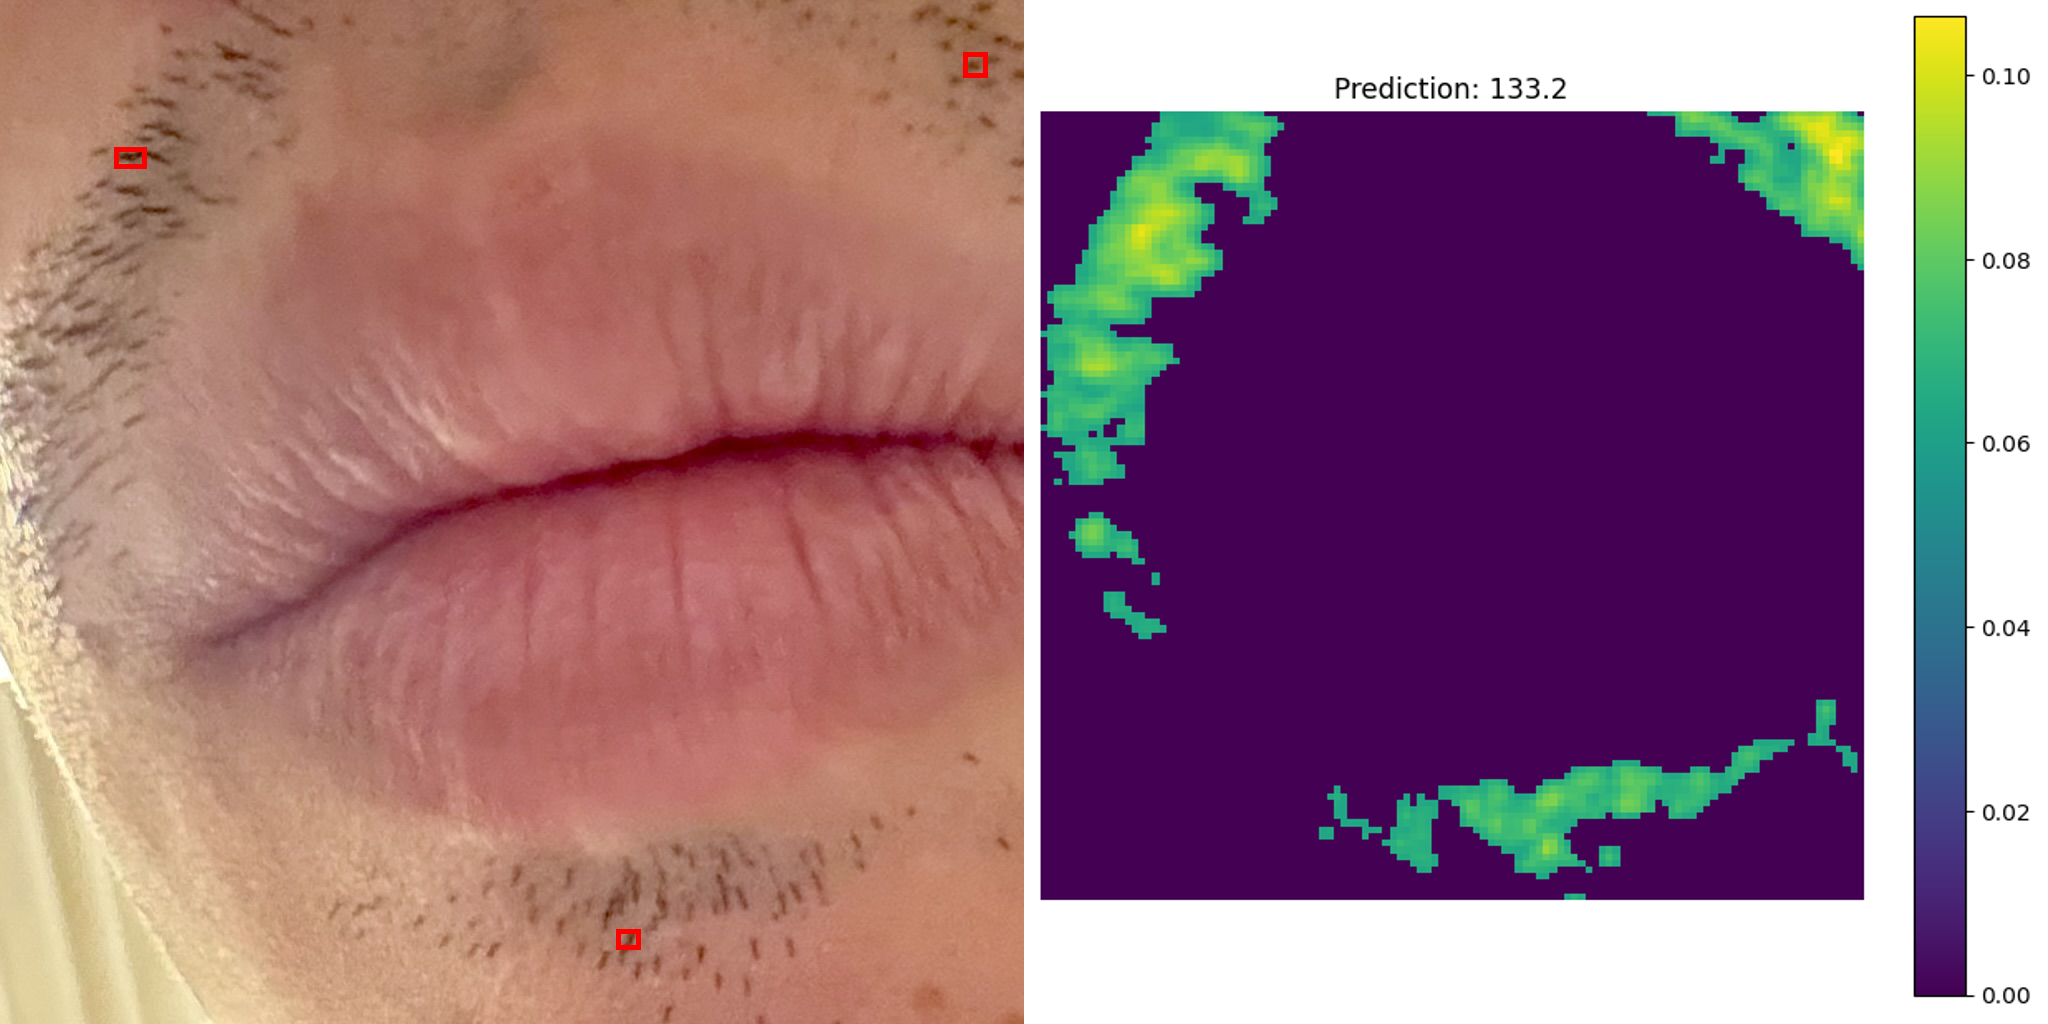

In [10]:
# 推論実行
gt_map, pred_map = process_example(
    os.path.basename(filepath),
    example, 
    model, transform, map_keys, 
    os.path.dirname(filepath) or '.', 
    None, 
    config, 
    return_maps=True,
    gt_count=0  # ← これ追加
)

# 可視化
# 4点形式 → (x1, y1, x2, y2) に変換して描画
ex_bboxes = [convert_4corners_to_x1y1x2y2(bbox) for bbox in example['box_examples_coordinates']]
# 赤い太枠で描画（見やすいようにwidth=5）
img_with_boxes = draw_bounding_boxes(img, ex_bboxes, color="red", width=5)

density_map = pred_map.cpu().numpy()
pred = density_map.sum().item()

to_plot_img = combine_pil_and_plot(
    original_img=img_with_boxes, 
    density_map=density_map, 
    title=f"Prediction: {pred:.1f}", 
)

to_plot_img